# cer-transfer demo

Reconstruct ion temperature and rotation profiles from CER spectrograms with a
pretrained model, and compare them with the conventional fits. Runs on CPU in
well under a minute.

Needs the repository (this notebook lives in `notebooks/`) with its environment
(`pixi install`; kernel "cer-transfer (pixi)"), `CER_DATA_ROOT` set, the checkpoint
in `cer_ckpts/` and one discharge file. **All choices are in the first code cell:**
machine, checkpoint, discharge, frame timing, chords.

In [1]:
# ---- configuration: everything below derives from these settings -------------
MACHINE = "d3d"       # "nstx" or "d3d"

PRESETS = {
    # "machine": dict(checkpoint, shot file, frames/s  time of frame 0 (s))
    "nstx": dict(ckpt="nstx_ft_inference.pt",
                 shot="chers_137711.joblib",
                 fs=200.0, t0=-0.235),
    "d3d":  dict(ckpt="d3d_transfer_source_inference.pt",
                 shot="194367.joblib",
                 fs=200.0, t0=0.0),
}
CHORDS = (13, 20)      # chords shown in the time-trace panel
RELEASE = "https://github.com/PlasmaControl/cer_transfer_learning/releases/download/v0.1"
# For D3D: 194367, 195604, 190308, 192667, 191804, 190010, 190006, 192693, 190012, 190011, 190053, 190972, 192660, 190048, 190049, 191056, 190310, 190309, 191057, 190252, 190311, 190381, 190051, 190312, 191062, 195706, 189954, 191922, 195596, 190050, 190313, 190295, 191060, 195685, 189978, 189953, 190382, 189970, 191065, 189979, 189966, 189965, 189975, 190378, 190383, 191064, 190364, 190005, 191063, 190405, 190009, 190008, 191059, 190004, 189943, 192997, 190007, 191058, 191061, 189952, 189951, 189950, 189944, 189949, 189947, 189948, 191916

In [2]:
import os, sys, urllib.request
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
from cer_transfer.configs import data_path

P = PRESETS[MACHINE]
if RELEASE:
    DEMO = ROOT / "demo"; DEMO.mkdir(exist_ok=True)
    CKPT, SHOT = DEMO / Path(P["ckpt"]).name, DEMO / Path(P["shot"]).name
    for f in (CKPT, SHOT):
        if not f.exists():
            print("downloading", f.name); urllib.request.urlretrieve(f"{RELEASE}/{f.name}", f)
else:
    CKPT, SHOT = ROOT / P["ckpt"], data_path(P["shot"])
print(f"machine:    {MACHINE}\ncheckpoint: {CKPT}\ndischarge:  {SHOT}")
assert CKPT.exists(), f"missing checkpoint {CKPT}"
assert SHOT.exists(), f"missing discharge file {SHOT} (CER_DATA_ROOT = {os.environ.get('CER_DATA_ROOT')})"
assert P["fs"] is not None, "frame timing for this machine not set in PRESETS (fs, t0)"


downloading 194367.joblib
machine:    d3d
checkpoint: /scratch/gpfs/EKOLEMEN/ps9551/cer_transfer_learning/demo/d3d_transfer_source_inference.pt
discharge:  /scratch/gpfs/EKOLEMEN/ps9551/cer_transfer_learning/demo/194367.joblib


## Load the model and run it on one discharge

In [3]:
from cer_transfer.inference import load_model, predict_file

m = load_model(CKPT)
print(f"machine {m.machine.name}: {m.machine.n_chords} chords, targets {list(m.machine.targets)}; "
      f"validation score {m.best_score:.3f}")

r = predict_file(m, SHOT)
C, T, _ = r.pred.shape
print(f"{C} chords x {T} frames; conventional fits on "
      f"{int((~__import__('numpy').isnan(r.y[..., 0])).sum())} of {C * T} chord-frames")

machine d3d: 80 chords, targets ['ti', 'vtor']; validation score 0.869
indexed 1 files in 0.0s (8.7 ms/file effective)
80 chords x 2000 frames; conventional fits on 11129 of 160000 chord-frames


`r.pred[chord, frame, k]` is the reconstruction (k = 0: T_i in eV, k = 1: v_tor in km/s),
`r.pred_sigma` its uncertainty, `r.y` / `r.sigma` the conventional fits where they exist.
NSTX CHERS records at 200 Hz; the recording starts 235 ms before the experimental clock zero.

## Time traces of two chords

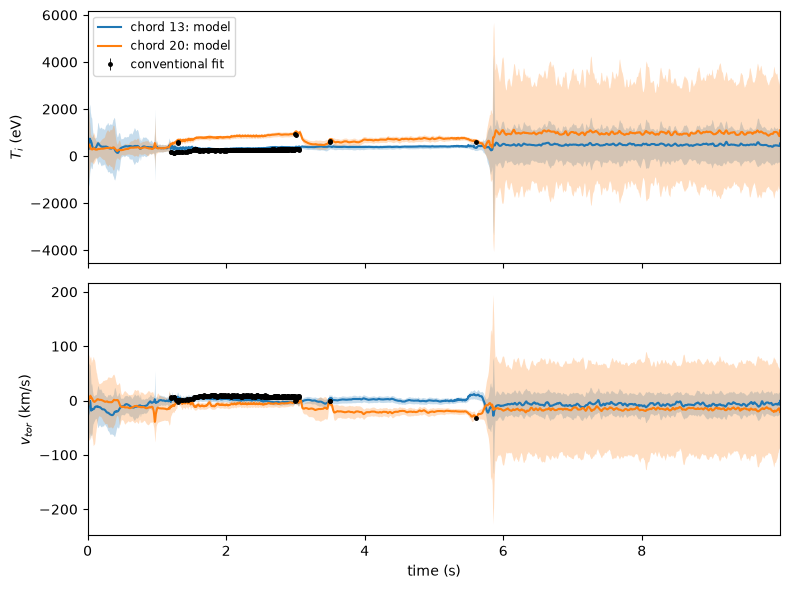

In [4]:
import numpy as np
import matplotlib.pyplot as plt

t = np.arange(T) / P["fs"] + P["t0"]        # frame timing from PRESETS
fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
for k, (ax, lab) in enumerate(zip(axes, ("$T_i$ (eV)", "$v_{tor}$ (km/s)"))):
    for i, c in enumerate(CHORDS):
        ax.fill_between(t, r.pred[c, :, k] - r.pred_sigma[c, :, k], r.pred[c, :, k] + r.pred_sigma[c, :, k],
                        color=f"C{i}", alpha=0.25, lw=0)
        ax.plot(t, r.pred[c, :, k], color=f"C{i}", lw=1.5, label=f"chord {c}: model")
        ok = np.isfinite(r.y[c, :, k])
        ax.errorbar(t[ok], r.y[c, ok, k], yerr=r.sigma[c, ok, k], fmt="o", ms=2.5, lw=0.6, color="k",
                    label="conventional fit" if i == 0 else None)
    ax.set_ylabel(lab); ax.set_xlim(0, t[-1])
axes[0].legend(fontsize="small"); axes[1].set_xlabel("time (s)")
plt.tight_layout()

## Profiles at one time, including chords without a conventional fit

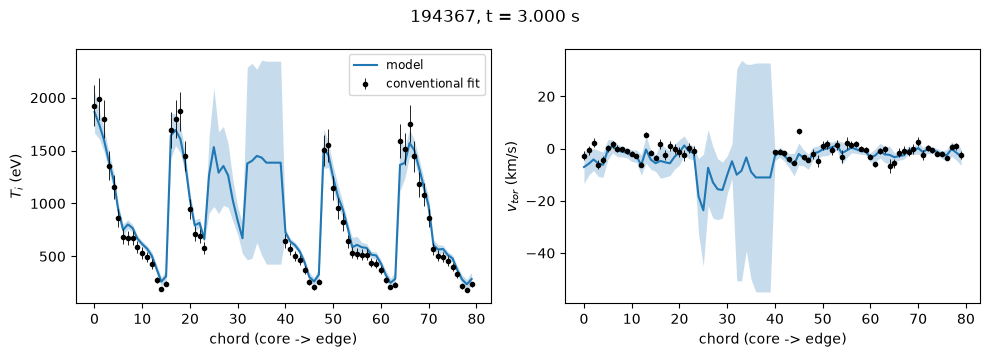

In [5]:
f = int(np.argmax(np.isfinite(r.y[:, :, 0]).sum(axis=0)))        # frame with the most fits
x = np.arange(C)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
for k, (ax, lab) in enumerate(zip(axes, ("$T_i$ (eV)", "$v_{tor}$ (km/s)"))):
    ax.fill_between(x, r.pred[:, f, k] - r.pred_sigma[:, f, k], r.pred[:, f, k] + r.pred_sigma[:, f, k],
                    color="C0", alpha=0.25, lw=0)
    ax.plot(x, r.pred[:, f, k], color="C0", lw=1.5, label="model")
    ok = np.isfinite(r.y[:, f, k])
    ax.errorbar(x[ok], r.y[ok, f, k], yerr=r.sigma[ok, f, k], fmt="o", ms=3, lw=0.6, color="k",
                label="conventional fit")
    ax.set_xlabel("chord (core -> edge)"); ax.set_ylabel(lab)
axes[0].legend(fontsize="small"); fig.suptitle(f"{SHOT.stem}, t = {t[f]:.3f} s")
plt.tight_layout()

The model returns values for every chord and frame; the conventional analysis
only where a Gaussian fit converged. For the background-array model and the
beam-off examples see `scripts/make_figs.sh` and `cer_transfer/figures/`.